In [52]:
import numpy as np
import json
import torch
from pathlib import Path

from src.models.TransformerBottleneck_model import TransformerBottleneck_model
from src.models.model_utilizer import load_net
from src.dataloaders.ZerosPolesDataset import ConversionTransforms

In [53]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is not available. PyTorch is using CPU.


## Настройки

In [54]:
threshold = 0.5

Пути к каталогам.

In [55]:
model_name = 'TransformerBottleneck-model_halfwindow_8'
sample_name = "1zp1lp0rp2lz0rz_004.csv"

config_dir = Path("./src/config/")

config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    general_config = json.load(f)

checkpoints_dir = Path(general_config['checkpoints_dir'])
logs_dir = Path(general_config['logs_dir'])

model_log_path = logs_dir / f"{model_name}.json"
assert model_log_path.exists(), f"Config not found: {model_log_path}"
with open(model_log_path, "r") as f:
    model_log = json.load(f)

train_log = model_log["train_log"]
best_epoch = model_log["summary"]["best_epoch"]
sample_path = Path("test_samples") / sample_name

In [56]:
device = torch.device(general_config["device"].lower() if torch.cuda.is_available() else 'cpu')

In [57]:
data = np.loadtxt(sample_path, delimiter=',', skiprows=1).T

transform = ConversionTransforms(
        num_iter=2,
        return_input=False
        )

inputs = torch.from_numpy(np.ascontiguousarray(transform(data), dtype=np.float32))

In [58]:
model = TransformerBottleneck_model(
    in_channels = 4,
    out_channels = 4,
    features = model_log["metadata"]["model"]["feature_list"]
    )

model = model.to(device)
model, _, _, _ = load_net(
            net = model,
            checkpoints_file = checkpoints_dir / f"best_{model_name}.pth",
            device = device
            )

model.eval()

with torch.no_grad():
    logits = model(inputs.unsqueeze(0).to(device))
    predictions = (torch.sigmoid(logits.squeeze(0)) > threshold).float()

Restoring checkpoint:  checkpoints\best_TransformerBottleneck-model_halfwindow_8.pth


In [76]:
PLOT_CONFIG = {
    'fontsize': 14,
    'fontsize_legend': 10,
    'fig_width': 8,
    'fig_height': 6,
    'markersize_data': 3,
    'markersize_mask': 10,
    'grid_alpha': 0.5,
    'plots': [
        {
            'ylabel': 'Magnitude, dB',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'mag'
        },
        {
            'ylabel': 'Phase, rad',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'ph'
        }
    ],
    'masks': [
        {'label': 'left_pole',  'color': '#e377c2', 'marker': 'o'},
        {'label': 'right_pole', 'color': '#d62728', 'marker': 'p'},
        {'label': 'left_zero',  'color': '#bcbd22', 'marker': 's'},
        {'label': 'right_zero', 'color': '#ff7f0e', 'marker': '^'},
    ]
}

In [ ]:
from typing import Union, Any, Dict, Optional, List
from matplotlib import pyplot as plt

def plot_responses(
    plot_config: Dict[str, Any],
    data: np.ndarray,
    regions: torch.Tensor,
    masks: Optional[List[int]] = None,
    save_path: Optional[Union[str, Path]] = None
    ) -> None:

    regions = regions.detach().cpu().numpy()
    x_samples = np.arange(regions.shape[-1])

    data_map = {
        'freq': data[0,:],
        'samples': x_samples,
        'mag'      : data[1,:],
        'ph'       : data[2,:]
    }

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(plot_config['fig_width'],
                 plot_config['fig_height'])
        )
    axs = np.array(axs).flatten()
    for idx, cfg in enumerate(plot_config['plots']):
        ax = axs[idx]
        
        # 1. Plot Main Data.
        x_data = data_map[cfg['arg_key']]
        y_data = data_map[cfg['data_key']]
        
        ax.plot(x_data, y_data, '.', markersize=plot_config['markersize_data'], 
                linestyle='-', alpha=0.7)

        if masks is not None:
            # 2. Plot Masks.
            has_mask = False
            for m_idx, m_cfg in enumerate(plot_config['masks']):
                indices = np.where(masks[m_idx] == 1)[0]
                
                if len(indices) > 0:
                    has_mask = True
                    ax.plot(x_data[indices], y_data[indices], 
                            marker=m_cfg['marker'], markersize=plot_config['markersize_mask'], 
                            linestyle='', color=m_cfg['color'], 
                            label=m_cfg['label'])

        # 3. Styling.
        #if idx == 0:
            # Only set title on the first plot of the sample group.
            #ax.set_title(f"Item {k}: {samples_list[k]}", fontsize=plot_config['fontsize'], fontweight='bold')
        ax.axvspan(3.5, 4.0, color='orange', alpha=0.25, label='Region of Interest')
        
        ax.set_xscale(cfg['xscale'])
        ax.set_ylabel(cfg['ylabel'], fontsize=plot_config['fontsize'])
        ax.set_xlabel(cfg['xlabel'], fontsize=plot_config['fontsize'])
        ax.grid(True, alpha=plot_config['grid_alpha'], axis='both', linestyle='--')
        
        # Only show legend if masks exist.
        #if has_mask:
        #    ax.legend(fontsize=plot_config['fontsize_legend'], loc='best', framealpha=0.8)

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    plt.show()
    plt.close(fig)

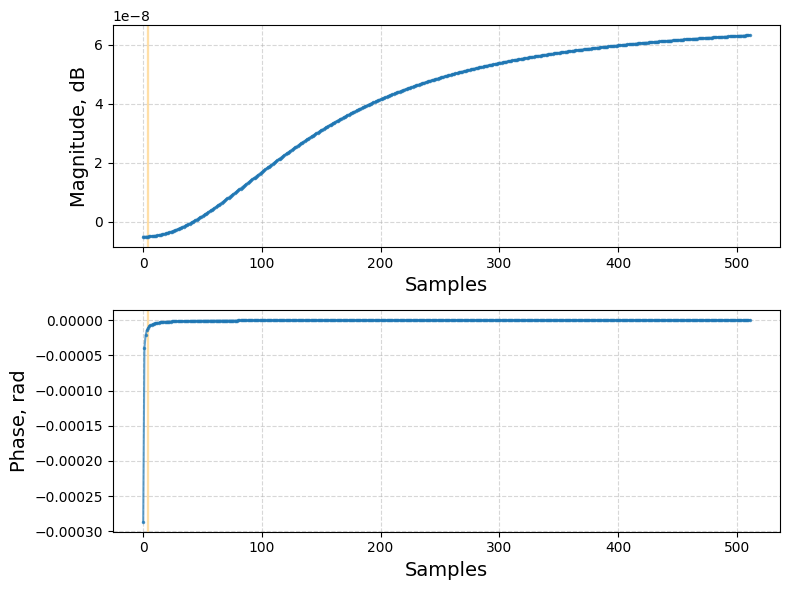

In [78]:
plot_responses(
    plot_config=PLOT_CONFIG,
    data=data,
    regions=predictions,
    ) 